In [ ]:

# Traffic Sign Detection and Recognition (GTSRB) using ResNet152V2 (32x32) with Data Augmentation
# ==============================================================================================
# Author: Gurpreet Kaur
# Model: ResNet152V2
# Dataset: German Traffic Sign Recognition Benchmark (GTSRB)
# Goal: Achieve high accuracy (>99%) with data augmentation and fine-tuning.

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping




✅ Total training samples: 39209
✅ Total test samples: 12630
📥 Loading training, validation, and test images...


In [ ]:
# =======================================
# Data Paths
# =======================================
DATA_DIR = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
train_csv = os.path.join(DATA_DIR, "train.csv")
test_csv = os.path.join(DATA_DIR, "test.csv")

# =======================================
# Load CSV Data
# =======================================
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

train_df = train_df[['Path', 'ClassId']]
test_df = test_df[['Path', 'ClassId']]

train_df['Path'] = train_df['Path'].apply(lambda x: os.path.join(DATA_DIR, x.replace('\\', '/')))
test_df['Path'] = test_df['Path'].apply(lambda x: os.path.join(DATA_DIR, x.replace('\\', '/')))

print("✅ Total training samples:", len(train_df))
print("✅ Total test samples:", len(test_df))

# =======================================
# Split train into train/validation
# =======================================
train_data, val_data = train_test_split(train_df, test_size=0.2, stratify=train_df['ClassId'], random_state=42)

# =======================================
# Helper to load and augment images
# =======================================
IMG_SIZE = (32, 32)

def load_images_from_df(df):
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['Path'], target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(row['ClassId'])
        except Exception as e:
            print(f"⚠️ Skipping {row['Path']} due to {e}")
    return np.array(images), np.array(labels)

print("📥 Loading training, validation, and test images...")
X_train, y_train = load_images_from_df(train_data)
X_val, y_val = load_images_from_df(val_data)
X_test, y_test = load_images_from_df(test_df)

# One-hot encode labels
num_classes = len(np.unique(y_train))
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_val = tf.keras.utils.to_categorical(y_val, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# =======================================
# Data Augmentation
# =======================================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=64, shuffle=True)
val_gen = val_datagen.flow(X_val, y_val, batch_size=64, shuffle=False)
test_gen = test_datagen.flow(X_test, y_test, batch_size=64, shuffle=False)

# =======================================


In [2]:
# Model Definition — ResNet152V2
# =======================================
base_model = ResNet152V2(weights=None, include_top=False, input_shape=(32,32,3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(num_classes, activati
               on='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# =======================================
# Callbacks
# =======================================
os.makedirs("models", exist_ok=True)
checkpoint = ModelCheckpoint("models/resnet152v2_gtsrb_32x32_aug.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

# =======================================
# Training
# =======================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)





Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 38, 38, 3)            0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 16, 16, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 18, 18, 64)           0         ['conv1_conv[0][0]']          
                                                                                            

d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


491/491 [==============================] - 517s 999ms/step - loss: 3.8742 - accuracy: 0.0552 - val_loss: 48434.4297 - val_accuracy: 0.0608 - lr: 0.0010
Epoch 2/30
491/491 [==============================] - ETA: 0s - loss: 3.8313 - accuracy: 0.0576
Epoch 2: val_accuracy did not improve from 0.06083
491/491 [==============================] - 476s 970ms/step - loss: 3.8313 - accuracy: 0.0576 - val_loss: 24.3927 - val_accuracy: 0.0536 - lr: 0.0010
Epoch 3/30
491/491 [==============================] - ETA: 0s - loss: 3.5139 - accuracy: 0.0577
Epoch 3: val_accuracy did not improve from 0.06083
491/491 [==============================] - 457s 931ms/step - loss: 3.5139 - accuracy: 0.0577 - val_loss: 4668034560.0000 - val_accuracy: 0.0536 - lr: 0.0010
Epoch 4/30
491/491 [==============================] - ETA: 0s - loss: 3.4919 - accuracy: 0.0549
Epoch 4: val_accuracy did not improve from 0.06083
491/491 [==============================] - 461s 938ms/step - loss: 3.4919 - accuracy: 0.0549 - val_lo

198/198 [==============================] - 28s 141ms/step - loss: 49682.6055 - accuracy: 0.0698
✅ Test Accuracy: 6.98%


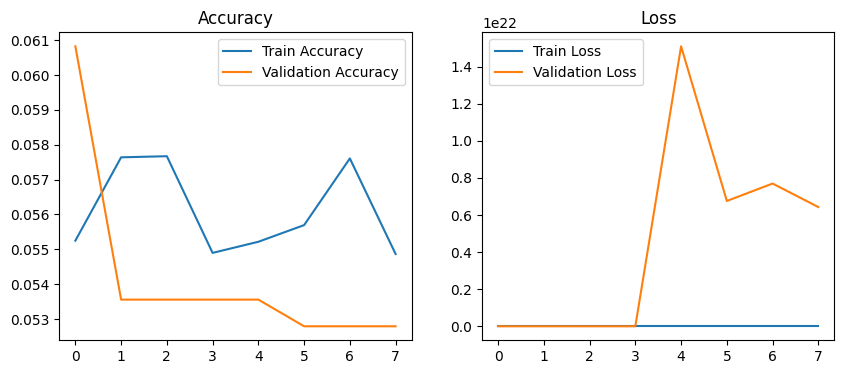

198/198 [==============================] - 46s 225ms/step

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.03      0.01      0.01       720
           2       0.00      0.00      0.00       750
           3       0.00      0.00      0.00       450
           4       0.00      0.00      0.00       660
           5       0.00      0.00      0.00       630
           6       0.00      0.00      0.00       150
           7       0.00      0.00      0.00       450
           8       0.00      0.00      0.00       450
           9       0.00      0.00      0.00       480
          10       0.14      0.42      0.21       660
          11       0.00      0.00      0.00       420
          12       0.04      0.08      0.06       690
          13       0.00      0.00      0.00       720
          14       0.00      0.00      0.00       270
          15       0.00      0.00      0.00       

d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

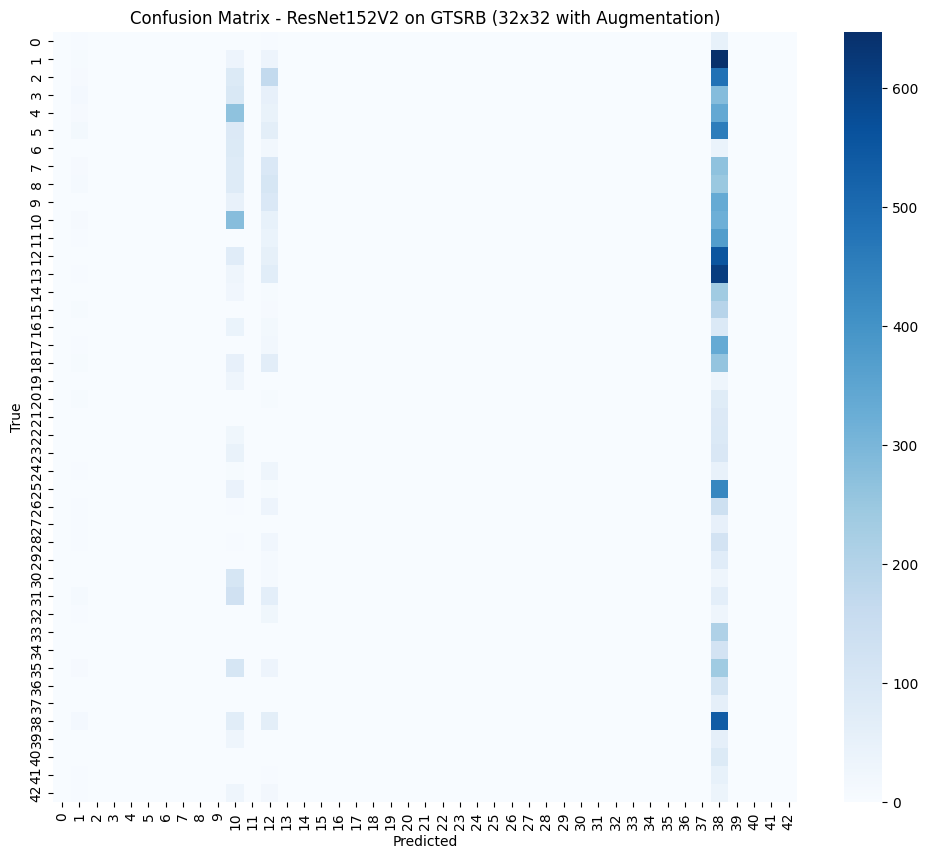

In [3]:
# =======================================
# Evaluation
# =======================================
model.load_weights("models/resnet152v2_gtsrb_32x32_aug.h5")
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

# =======================================
# Accuracy & Loss Curves
# =======================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# =======================================
# Classification Report & Confusion Matrix
# =======================================
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet152V2 on GTSRB (32x32 with Augmentation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
